<a href="https://colab.research.google.com/github/nikeanan/project-of-concrete-strength-prediction-using-various-ML-models/blob/main/concrete_strength_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Concrete Compressive Strength Prediction

## Project Overview

This project aims to predict the compressive strength of concrete based on its composition and curing age. Concrete compressive strength is a critical property in construction, and accurate prediction can optimize material usage, reduce costs, and ensure structural integrity. This notebook explores various machine learning models, from traditional linear regression to advanced deep learning and ensemble methods, to find the most effective predictive solution.

## Dataset

The dataset used in this project is sourced from Kaggle: [Concrete Compressive Strength](https://www.kaggle.com/datasets/niteshyadav3103/concrete-compressive-strength).

It contains 8 input features representing the composition of concrete (e.g., Cement, Water, Fly Ash, Superplasticizer, Coarse Aggregate, Fine Aggregate, Blast Furnace Slag) and one input feature for 'Age (day)'. The target variable is 'Concrete compressive strength'.

## Methodology

The project follows a comprehensive machine learning pipeline:

1.  **Data Loading & Initial Inspection**: The data is loaded from the CSV file, and initial checks are performed for missing values and data types.
2.  **Exploratory Data Analysis (EDA)**: Visualizations (scatter matrix, correlation heatmap) are used to understand relationships between features and the target variable, identify potential multicollinearity, and gain insights into the data distribution.
3.  **Feature Engineering**: New features, such as 'w_c_ratio' (water-cement ratio), 'binder', and 'w_b_ratio' (water-binder ratio), are created based on domain knowledge.
4.  **Model Development & Evaluation (Regression)**:
    *   **Keras Linear Regression**: A simple Keras model is built and trained to establish a baseline. Different kernel and bias initializers are experimented with.
    *   **Scikit-learn Linear Regression**: A traditional linear regression model is implemented and compared. Multicollinearity issues with engineered features are addressed by retraining the model without the highly correlated ratios.
    *   **Ridge and Lasso Regression**: Regularized linear models are employed to handle potential multicollinearity and perform feature selection.
    *   **K-Nearest Neighbors (kNN) Regression**: A non-linear, instance-based model is used.
    *   **Random Forest Regressor**: A powerful ensemble tree-based model is implemented and hyperparameter-tuned using `GridSearchCV`.
    *   **Keras Deep Model**: A multi-layer perceptron (MLP) is built, incorporating hidden layers, activation functions, regularization (L2), batch normalization, and early stopping. Hyperparameter tuning is performed using `GridSearchCV` with `scikeras.wrappers.KerasRegressor`.
5.  **Model Development & Evaluation (Classification)**:
    *   **Logistic Regression**: The continuous target variable is categorized into low, medium, and high strength classes. A Logistic Regression model is trained and evaluated using accuracy, confusion matrix, and classification report. Hyperparameter tuning for Logistic Regression is also performed with `GridSearchCV`.
6.  **Ensemble Method**: A simple averaging ensemble of the best-performing Random Forest and Keras Deep models is created to potentially improve predictive performance.
7.  **Model Interpretability**: SHAP (SHapley Additive exPlanations) values are used to explain the predictions of the Random Forest model, providing insights into feature importance and their impact on individual predictions.
8.  **Performance Comparison**: A summary table compares the R2 score and Mean Absolute Error (MAE) of all implemented regression models on their respective test sets.

## Key Findings

*   **Feature Importance**: Features like 'Age (day)', 'Cement', 'Water', and engineered features like 'binder' consistently showed high importance across various models.
*   **Multicollinearity**: The engineered features `w_c_ratio` and `w_b_ratio` introduced significant multicollinearity, negatively impacting the stability and interpretability of simple Linear Regression coefficients. Removing them stabilized the linear models.
*   **Model Performance**: Tree-based models (e.g., Random Forest) and Keras deep learning models generally outperformed traditional linear models and kNN for this dataset, achieving significantly lower MAE and higher R2 scores. The Random Forest Regressor consistently showed very strong performance.
*   **Ensemble Benefits**: The simple averaging ensemble slightly improved upon the individual best models, demonstrating the potential of combining diverse models.
*   **Classification**: Logistic Regression provided reasonable classification performance, highlighting the viability of categorizing concrete strength for specific applications.

## Setup and Usage

To run this notebook, you will need a Google Colab environment or a local Python environment with the following dependencies:

### Dependencies

Install the required packages using pip:

```bash
!pip uninstall -y keras tensorflow scikeras scikit-learn
!pip install tensorflow~=2.18.0 \
  google-ml-edu==0.1.3 \
  matplotlib~=3.10.0 \
  numpy~=2.0.0 \
  pandas~=2.2.0
!pip install scikit-learn==1.4.2 scikeras==0.13.0
!pip install shap
```

### How to Run

1.  **Open in Google Colab**: Click the "Open in Colab" badge (if provided) or upload the `.ipynb` file to your Google Drive and open it with Collaboratory.
2.  **Run Cells**: Execute the notebook cells sequentially. The notebook is structured to walk through data loading, EDA, model training, evaluation, and interpretability.

## Future Enhancements

*   **More Advanced Feature Engineering**: Explore other polynomial or interaction features.
*   **Hyperparameter Tuning Optimization**: Utilize more sophisticated tuning libraries (e.g., Keras Tuner, Optuna) for deep learning models.
*   **Robust Cross-Validation for all Models**: Implement K-fold cross-validation for all models to get more robust performance estimates.
*   **Ensemble Stacking/Blending**: Explore more advanced ensemble techniques beyond simple averaging.
*   **Data Augmentation**: Investigate techniques to augment the dataset if limited data is a concern.
*   **Deployment**: Consider packaging the best model for deployment using frameworks like TensorFlow Serving or Flask.

In [ ]:
# Uninstall potential conflicting packages first
!pip uninstall -y keras tensorflow scikeras scikit-learn

# Install desired versions
# tensorflow~=2.18.0 should pull in keras 3.x (tf.keras or standalone Keras if preferred by pip)
!pip install tensorflow~=2.18.0 \
  google-ml-edu==0.1.3 \
  matplotlib~=3.10.0 \
  numpy~=2.0.0 \
  pandas~=2.2.0

# Install scikit-learn and scikeras explicitly
!pip install scikit-learn==1.4.2 scikeras==0.13.0

print('\n\nAll requirements successfully installed.')

Found existing installation: keras 3.13.2
Uninstalling keras-3.13.2:
  Successfully uninstalled keras-3.13.2
Found existing installation: tensorflow 2.20.0
Uninstalling tensorflow-2.20.0:
  Successfully uninstalled tensorflow-2.20.0
Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.6/615.6 MB 719.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 68.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 106.5 MB/s eta 0:00:00
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.20.0
    Uninstalling tensorboard-2.20.0:
      Successfully uninstalled tensorboard-2.20.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tf-keras 2.20.0 requires tensorflow<2.21,>=2.20, but y

In [ ]:
# data
import numpy as np
import pandas as pd

# machine learning
import keras
import ml_edu.experiment
import ml_edu.results

# data visualization
import plotly.express as px

## DATA LOADING

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("niteshyadav3103/concrete-compressive-strength")

100%|██████████| 14.1k/14.1k [00:00<00:00, 7.80MB/s]

Extracting files...


In [ ]:
import os
concrete_strength_prediction = pd.read_csv(os.path.join(path, "Concrete Compressive Strength.csv"))

In [ ]:
print(concrete_strength_prediction.columns)

Index(['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer',
       'Coarse Aggregate', 'Fine Aggregate', 'Age (day)',
       'Concrete compressive strength '],
      dtype='object')


In [ ]:
training_df = concrete_strength_prediction.loc[:, ('Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer',
       'Coarse Aggregate', 'Fine Aggregate', 'Age (day)',
       'Concrete compressive strength ')]
training_df.head(1030)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age (day),Concrete compressive strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.284354
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.178794
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.696601
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.768036


In [ ]:


print(f"total no. of rows: {training_df.info}")

total no. of rows: <bound method DataFrame.info of       Cement  Blast Furnace Slag  Fly Ash  Water  Superplasticizer  \
0      540.0                 0.0      0.0  162.0               2.5   
1      540.0                 0.0      0.0  162.0               2.5   
2      332.5               142.5      0.0  228.0               0.0   
3      332.5               142.5      0.0  228.0               0.0   
4      198.6               132.4      0.0  192.0               0.0   
...      ...                 ...      ...    ...               ...   
1025   276.4               116.0     90.3  179.6               8.9   
1026   322.2                 0.0    115.6  196.0              10.4   
1027   148.5               139.4    108.6  192.7               6.1   
1028   159.1               186.7      0.0  175.6              11.3   
1029   260.9               100.5     78.3  200.6               8.6   

      Coarse Aggregate  Fine Aggregate  Age (day)  \
0               1040.0           676.0         28   
1 

In [ ]:
training_df.describe(include='all')

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age (day),Concrete compressive strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


In [ ]:
missing_values = training_df.isnull().sum().sum()
print(missing_values)

0


In [ ]:
training_df.corr(numeric_only = True)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age (day),Concrete compressive strength
Cement,1.000000,-0.275193,-0.397475,-0.081544,0.092771,-0.109356,-0.222720,0.081947,0.497833
Blast Furnace Slag,-0.275193,1.000000,-0.323569,0.107286,0.043376,-0.283998,-0.281593,-0.044246,0.134824
Fly Ash,-0.397475,-0.323569,1.000000,-0.257044,0.377340,-0.009977,0.079076,-0.154370,-0.105753
Water,-0.081544,0.107286,-0.257044,1.000000,-0.657464,-0.182312,-0.450635,0.277604,-0.289613
Superplasticizer,0.092771,0.043376,0.377340,-0.657464,1.000000,-0.266303,0.222501,-0.192717,0.366102
Coarse Aggregate,-0.109356,-0.283998,-0.009977,-0.182312,-0.266303,1.000000,-0.178506,-0.003016,-0.164928
Fine Aggregate,-0.222720,-0.281593,0.079076,-0.450635,0.222501,-0.178506,1.000000,-0.156094,-0.167249
Age (day),0.081947,-0.044246,-0.154370,0.277604,-0.192717,-0.003016,-0.156094,1.000000,0.328877
Concrete compressive strength,0.497833,0.134824,-0.105753,-0.289613,0.366102,-0.164928,-0.167249,0.328877,1.000000


In [ ]:
input_features = [
    'Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water',
    'Superplasticizer', 'Coarse Aggregate', 'Fine Aggregate',
    'Age (day)', 'w_c_ratio', 'binder', 'w_b_ratio'
]

## Exploratory Data Analysis (EDA)

In [ ]:
fig = px.scatter_matrix(
    training_df,
    dimensions=[
        'Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water',
        'Superplasticizer', 'Coarse Aggregate', 'Fine Aggregate',
        'Age (day)', 'Concrete compressive strength '
    ],
    width=1200,  # Set width in pixels
    height=1200  # Set height in pixels
)
fig.show()

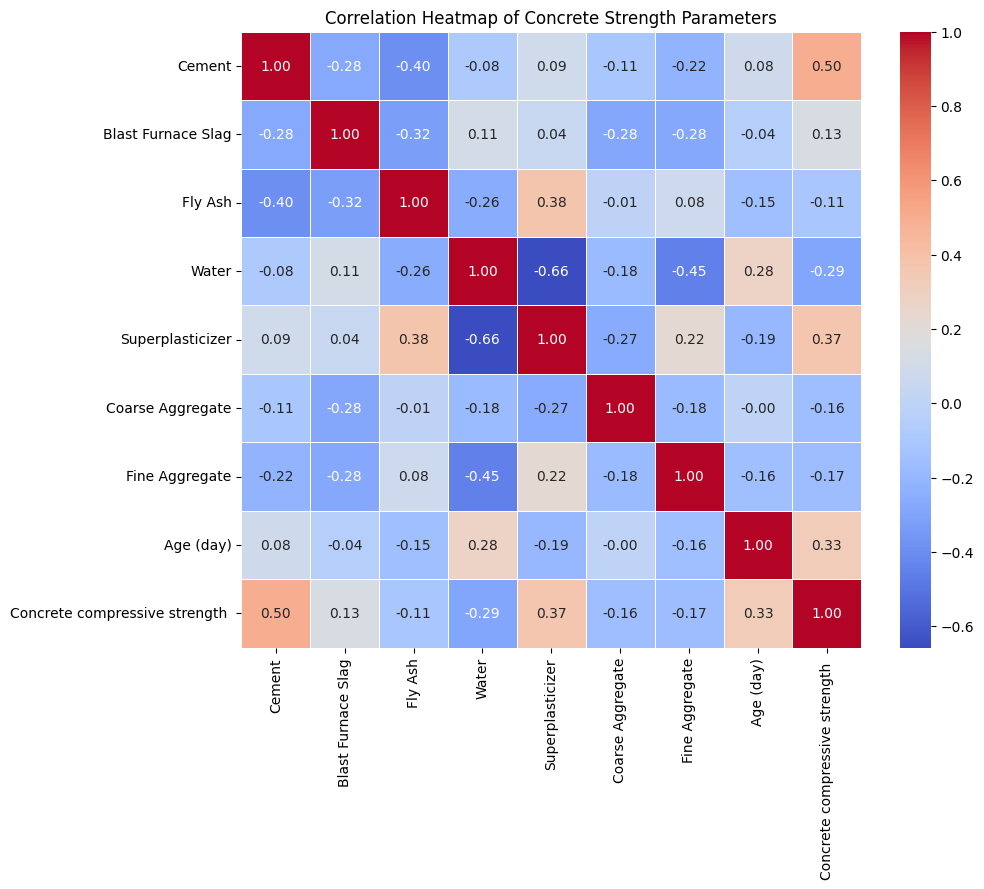

In [ ]:
#Strength is governed mainly by:
#Cement (binder),Water (weakening factor),Age (curing)
#This directly supports: Water–Cement Ratio Theory

import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
corr_matrix = training_df.corr()

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Concrete Strength Parameters')
plt.show()  # positive coorelation implies directly relationship, negative one implies inverse relationship

## KERAS LINEAR REGRESSION MODEL

In [ ]:
def create_model(
    settings: ml_edu.experiment.ExperimentSettings,
    metrics: list[keras.metrics.Metric],
    kernel_initializer: str = 'glorot_uniform', # Default Keras initializer for weights
    bias_initializer: str = 'zeros'             # Default Keras initializer for biases
) -> keras.Model:
  """Create and compile a simple linear regression model."""
  # Describe the topography of the model.
  # The topography of a simple linear regression model
  # is a single node in a single layer.
  inputs = {name: keras.Input(shape=(1,), name=name) for name in settings.input_features}
  concatenated_inputs = keras.layers.Concatenate()(list(inputs.values()))
  outputs = keras.layers.Dense(units=1, kernel_initializer=kernel_initializer, bias_initializer=bias_initializer)(concatenated_inputs)
  model = keras.Model(inputs=inputs, outputs=outputs)

  # Compile the model topography into code that Keras can efficiently
  # execute. Configure training to minimize the model's mean squared error.
  model.compile(optimizer=keras.optimizers.RMSprop(learning_rate=settings.learning_rate),
                loss="mean_squared_error",
                metrics=metrics)

  return model


def train_model(
    experiment_name: str,
    model: keras.Model,
    dataset: pd.DataFrame,
    label_name: str,
    settings: ml_edu.experiment.ExperimentSettings,
    callbacks: list[keras.callbacks.Callback] = None # Added callbacks parameter
) -> ml_edu.experiment.Experiment:
  """Train the model by feeding it data."""

  # Feed the model the feature and the label.
  # The model will train for the specified number of epochs.
  features = {name: dataset[name].values for name in settings.input_features}
  label = dataset[label_name].values
  history = model.fit(x=features,
                      y=label,
                      batch_size=settings.batch_size,
                      epochs=settings.number_epochs,
                      callbacks=callbacks) # Pass callbacks to model.fit

  return ml_edu.experiment.Experiment(
      name=experiment_name,
      settings=settings,
      model=model,
      epochs=history.epoch,
      metrics_history=pd.DataFrame(history.history),
  )

print("SUCCESS: defining linear regression functions complete.")

SUCCESS: defining linear regression functions complete.


Epoch 1/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 702266.5625 - rmse: 838.0135
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 613417.6875 - rmse: 783.2098
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 538953.1250 - rmse: 734.1343
Epoch 4/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 470156.1875 - rmse: 685.6794
Epoch 5/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 406377.6875 - rmse: 637.4776
Epoch 6/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 347464.3438 - rmse: 589.4611
Epoch 7/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 293253.5000 - rmse: 541.5289
Epoch 8/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 243838.2344 - rmse: 493.7998
Epoch 9/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 199424.6562 - rmse: 446.5699
Epoch 10/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 159661.2344 - rmse: 399.5763
Epoch 11/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 124588.8125 - rmse: 352.9714
Epoch 12/20
21/21 ━━━━━━━━━━━━━━━━━━━

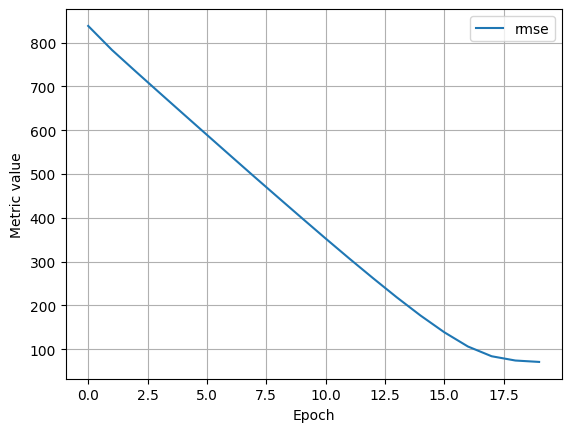

In [ ]:
settings_1 = ml_edu.experiment.ExperimentSettings(
    learning_rate = 0.001,
    number_epochs = 20,
    batch_size = 50,
    input_features = ['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer',
       'Coarse Aggregate', 'Fine Aggregate', 'Age (day)']
)

metrics = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_1 = create_model(settings_1, metrics)

experiment_1 = train_model('one_feature', model_1, training_df, 'Concrete compressive strength ', settings_1)

ml_edu.results.plot_experiment_metrics(experiment_1, ['rmse'])
# ml_edu.results.plot_model_predictions(experiment_1, training_df, 'Concrete compressive strength ')

Epoch 1/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5334.9189 - rmse: 72.0448 
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 692.3581 - rmse: 26.3127
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 431.3615 - rmse: 20.7692
Epoch 4/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 310.1606 - rmse: 17.6114
Epoch 5/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 258.0362 - rmse: 16.0635
Epoch 6/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 217.8671 - rmse: 14.7603
Epoch 7/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 220.2207 - rmse: 14.8398
Epoch 8/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 215.1948 - rmse: 14.6695
Epoch 9/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 193.5719 - rmse: 13.9130
Epoch 10/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 182.8549 - rmse: 13.5224
Epoch 11/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 187.6289 - rmse: 13.6978
Epoch 12/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 165.8981 - rmse: 12.

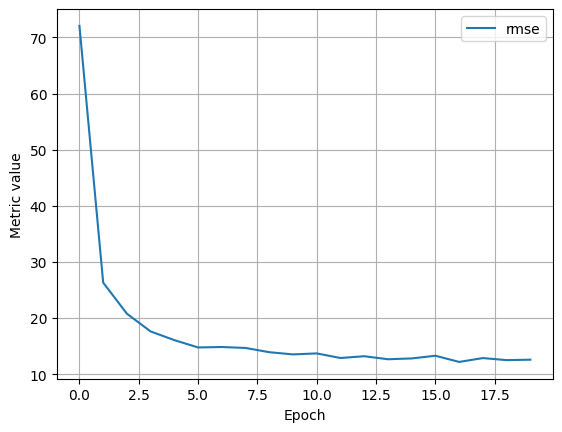

In [ ]:
settings_2 = ml_edu.experiment.ExperimentSettings(
    learning_rate = 0.005,
    number_epochs = 20,
    batch_size = 50,
    input_features = ['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer',
       'Coarse Aggregate', 'Fine Aggregate', 'Age (day)']
)

# Create a second model with fixed initializers
model_2 = create_model(settings_2, metrics, kernel_initializer='glorot_normal', bias_initializer='zeros')

experiment_2 = train_model('fixed_initializers', model_2, training_df, 'Concrete compressive strength ', settings_2)

ml_edu.results.plot_experiment_metrics(experiment_2, ['rmse'])

# Compare RMSE of both models
print(f"\nRMSE of Model 1 (default initializers): {experiment_1.metrics_history['rmse'].iloc[-1]:.4f}")
print(f"RMSE of Model 2 (glorot_normal kernel, zeros bias): {experiment_2.metrics_history['rmse'].iloc[-1]:.4f}")

## KERAS MODEL ANALYSIS

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


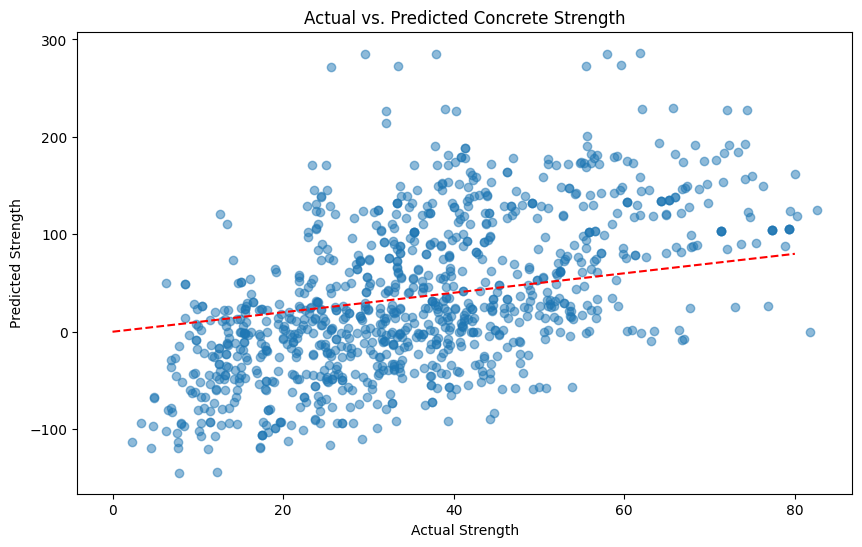

In [ ]:
# Generate predictions
predictions = model_1.predict({name: training_df[name].values for name in settings_1.input_features})

# Create the plot
plt.figure(figsize=(10, 6))
plt.scatter(training_df['Concrete compressive strength '], predictions, alpha=0.5)
plt.plot([0, 80], [0, 80], color='red', linestyle='--') # Diagonal reference line
plt.xlabel('Actual Strength')
plt.ylabel('Predicted Strength')
plt.title('Actual vs. Predicted Concrete Strength')
plt.show()

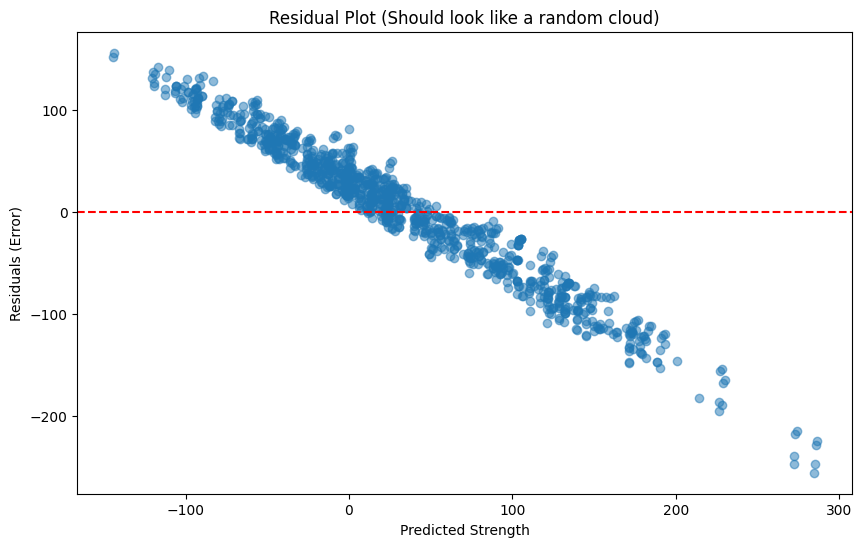

In [ ]:
residuals = training_df['Concrete compressive strength '].values.flatten() - predictions.flatten()

plt.figure(figsize=(10, 6))
plt.scatter(predictions, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Strength')
plt.ylabel('Residuals (Error)')
plt.title('Residual Plot (Should look like a random cloud)')
plt.show()

## FEATURE ENGINEERING

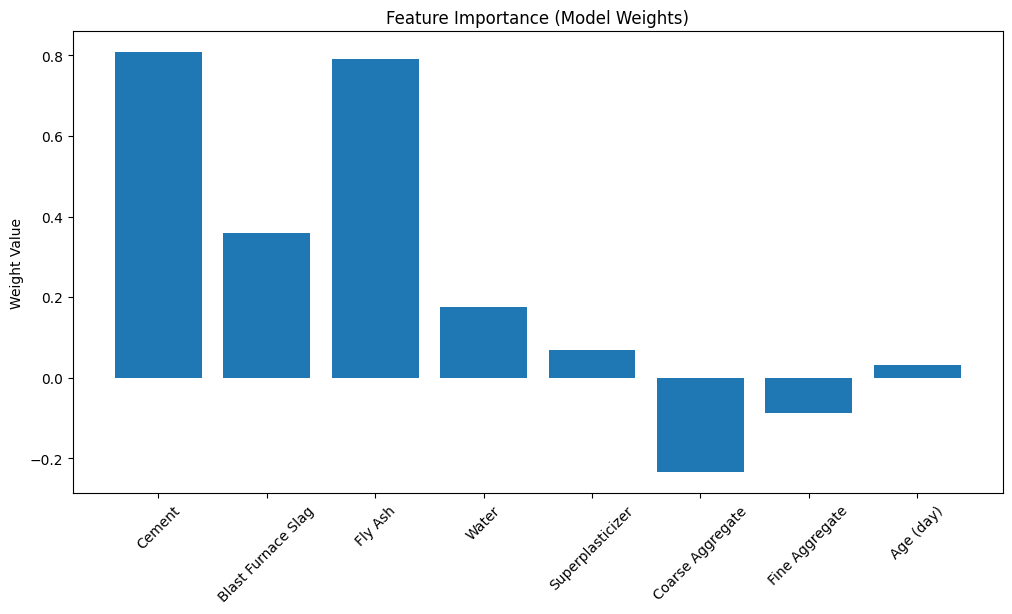

In [ ]:
# Get weights from the Dense layer
weights, bias = model_1.layers[-1].get_weights()
feature_names = settings_1.input_features

# Plotting the weights
plt.figure(figsize=(12, 6))
plt.bar(feature_names, weights.flatten())
plt.xticks(rotation=45)
plt.ylabel('Weight Value')
plt.title('Feature Importance (Model Weights)')
plt.show()

## Scikit-learn Linear Regression

A traditional scikit-learn Linear Regression model to compare against the Keras model.

In [ ]:
training_df["w_c_ratio"] = training_df["Water"] / training_df["Cement"]

training_df["binder"] = (
    training_df["Cement"] +
    training_df["Blast Furnace Slag"] +
    training_df["Fly Ash"]
)

training_df["w_b_ratio"] = training_df["Water"] / training_df["binder"]

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = training_df[input_features]
y = training_df['Concrete compressive strength ']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (824, 11)
X_test shape: (206, 11)
y_train shape: (824,)
y_test shape: (206,)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression R2:", r2_score(y_test, y_pred_lr))

Linear Regression R2: 0.6329230135172261


## Scikit-learn Linear Regression Visualizations

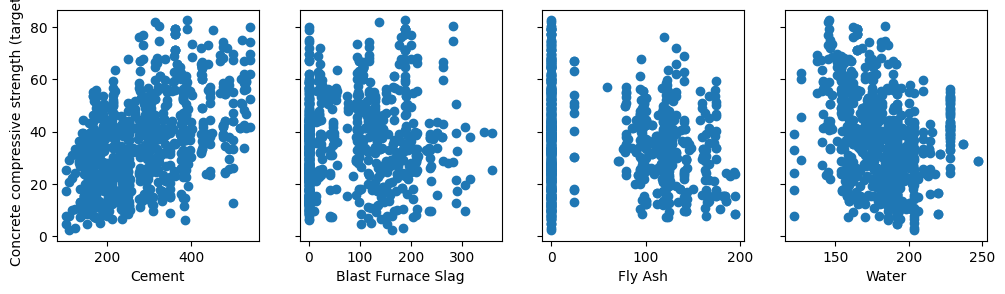

In [ ]:
import matplotlib.pyplot as plt

# share common same y-axis label
fig,ax=plt.subplots(1, 4, figsize=(12, 3), sharey=True)
# Convert X_train to a numpy array for direct indexing
X_train_np = X_train.values

for i in range(len(ax)):
    ax[i].scatter(X_train_np[:,i],y_train)
    ax[i].set_xlabel(input_features[i]) # Corrected typo from input_featuress
ax[0].set_ylabel("Concrete compressive strength (target))")
plt.show()

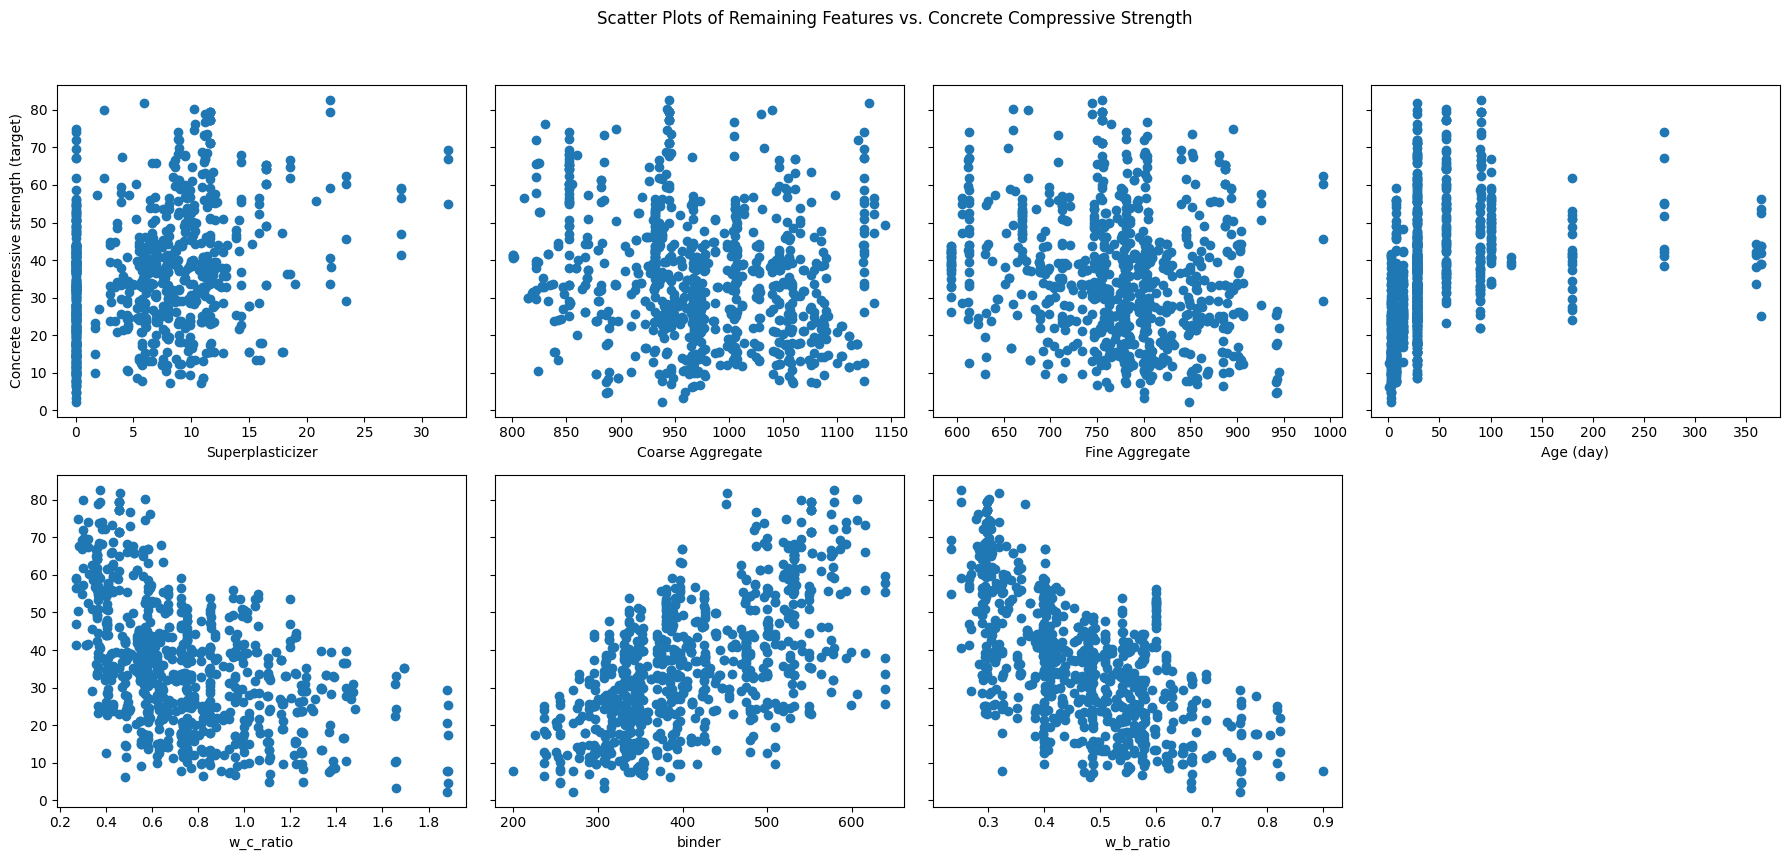

In [ ]:
import matplotlib.pyplot as plt

# Get the remaining input features
remaining_features = input_features[4:]
start_index = 4 # Start index in the X_train_np array

# Create subplots for the remaining features
# We have 7 remaining features, so a 2x4 grid works (one subplot will be empty)
fig, axs = plt.subplots(2, 4, figsize=(18, 9), sharey=True)
axs = axs.flatten() # Flatten the 2D array of axes for easy iteration

for idx, feature_name in enumerate(remaining_features):
    if idx < len(axs):
        current_ax = axs[idx]
        # X_train_np has all features, so we use the correct index
        current_ax.scatter(X_train_np[:, start_index + idx], y_train)
        current_ax.set_xlabel(feature_name)

# Set the y-label for the first subplot in the new figure
axs[0].set_ylabel("Concrete compressive strength (target)")

# Hide any unused subplots (if any, in case of a non-perfect grid fit)
for i in range(len(remaining_features), len(axs)):
    fig.delaxes(axs[i])

plt.suptitle('Scatter Plots of Remaining Features vs. Concrete Compressive Strength')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

## K-Nearest Neighbors (kNN) Regression

In [ ]:
def compute_cost(X, y, w, b):
    """
    compute cost
    Args:
      X (ndarray (m,n)): Data, m examples with n features
      y (ndarray (m,)) : target values
      w (ndarray (n,)) : model parameters
      b (scalar)       : model parameter

    Returns:
      cost (scalar): cost
    """
    m = X.shape[0]
    cost = 0.0
    for i in range(m):
        f_wb_i = np.dot(X[i], w) + b           #(n,)(n,) = scalar (see np.dot)
        cost = cost + (f_wb_i - y[i])**2       #scalar
    cost = cost / (2 * m)                      #scalar
    return cost

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("kNN R2:", r2_score(y_test, y_pred_knn))

kNN R2: 0.7178654216970255


##Logistic Regression clsassifcation of strength of concrete

In [ ]:
def categorize_strength(val):
    if val < 30:
        return 0
    elif val < 50:
        return 1
    else:
        return 2

training_df["strength_class"] = training_df["Concrete compressive strength "].apply(categorize_strength)

X = training_df.drop(["Concrete compressive strength ", "strength_class"], axis=1)
y = training_df["strength_class"]

print("New X shape:", X.shape)
print("New y shape:", y.shape)
print("Strength class distribution:\n", y.value_counts())

New X shape: (1030, 11)
New y shape: (1030,)
Strength class distribution:
 strength_class
1    422
0    398
2    210
Name: count, dtype: int64


### Refactoring Logistic Regression into a Function

To improve code reusability and maintainability, the Logistic Regression classification pipeline will be encapsulated into a single function. This function will handle:

*   Splitting the data into training and testing sets.
*   Scaling the features using `StandardScaler`.
*   Training a `LogisticRegression` model.
*   Making predictions on the test set.
*   Calculating and returning the accuracy, confusion matrix, and classification report.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

def train_and_evaluate_logistic_regression(
    X_data: pd.DataFrame,
    y_data: pd.Series,
    test_size: float = 0.2,
    random_state: int = 42,
    max_iter: int = 5000,
    solver: str = 'lbfgs',
    class_weight: str = None  # Added class_weight parameter
):
  """
  Trains and evaluates a Logistic Regression model with a StandardScaler pipeline.

  Args:
      X_data: DataFrame of features.
      y_data: Series of target labels.
      test_size: Proportion of the dataset to include in the test split.
      random_state: Controls the shuffling applied to the data before applying the split.
      max_iter: Maximum number of iterations taken for the solvers to converge.
      solver: Algorithm to use in the optimization problem.
      class_weight: Dictionary or 'balanced'. Weights associated with classes.

  Returns:
      A tuple containing: (accuracy_score, confusion_matrix, classification_report_dict, y_test, y_pred)
  """
  X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=test_size, random_state=random_state)

  log_pipeline = Pipeline([
      ("scaler", StandardScaler()),
      ("logreg", LogisticRegression(max_iter=max_iter, solver=solver, class_weight=class_weight))
  ])

  log_pipeline.fit(X_train, y_train)
  y_pred = log_pipeline.predict(X_test)

  accuracy = accuracy_score(y_test, y_pred)
  cm = confusion_matrix(y_test, y_pred)
  report = classification_report(y_test, y_pred, output_dict=True)

  return accuracy, cm, report, y_test, y_pred

print("Logistic Regression pipeline function defined.")

Logistic Regression pipeline function defined.


Now, let's use the new function to train and evaluate our Logistic Regression model.

Logistic Regression Accuracy (with balanced class weights): 0.7136


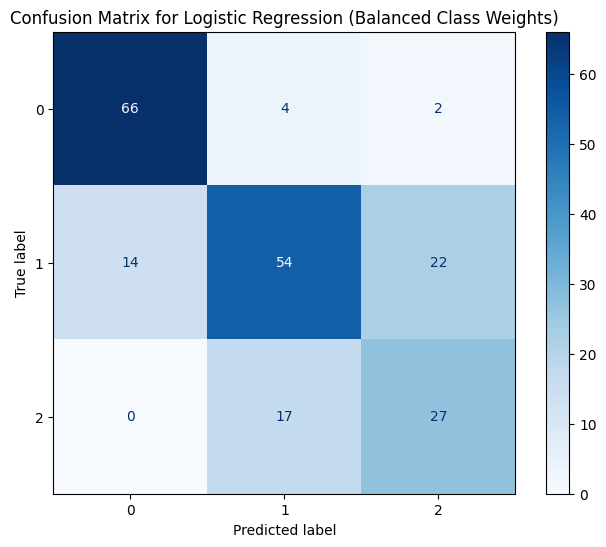


Classification Report (Balanced Class Weights):

                  precision    recall  f1-score   support

   Class 0 (Low)       0.82      0.92      0.87        72
Class 1 (Medium)       0.72      0.60      0.65        90
  Class 2 (High)       0.53      0.61      0.57        44

        accuracy                           0.71       206
       macro avg       0.69      0.71      0.70       206
    weighted avg       0.72      0.71      0.71       206



In [ ]:
# Run the refactored Logistic Regression pipeline with class_weight='balanced'
log_accuracy, log_cm, log_report, y_test_logreg, y_pred_logreg = train_and_evaluate_logistic_regression(X, y, class_weight='balanced')

print(f"Logistic Regression Accuracy (with balanced class weights): {log_accuracy:.4f}")

# Display Confusion Matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=log_cm, display_labels=[0, 1, 2])
disp.plot(cmap=plt.cm.Blues, ax=plt.gca())
plt.title('Confusion Matrix for Logistic Regression (Balanced Class Weights)')
plt.show()

# Display Classification Report
print("\nClassification Report (Balanced Class Weights):\n")
print(classification_report(y_test_logreg, y_pred_logreg, target_names=['Class 0 (Low)', 'Class 1 (Medium)', 'Class 2 (High)']))

### Hyperparameter Grid Search for Logistic Regression

Now, let's perform a hyperparameter grid search to find the optimal parameters for our Logistic Regression model, particularly focusing on the regularization strength (`C`) and confirming the `class_weight` setting.

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters found: {'logreg__C': 10, 'logreg__class_weight': 'balanced'}
Best F1-macro score: 0.7486

Best Logistic Regression Accuracy on Test Set: 0.7184


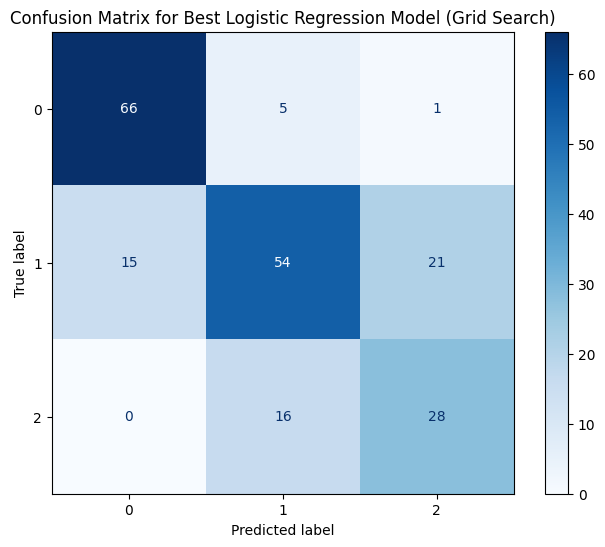


Classification Report for Best Logistic Regression Model (Grid Search):

                  precision    recall  f1-score   support

   Class 0 (Low)       0.81      0.92      0.86        72
Class 1 (Medium)       0.72      0.60      0.65        90
  Class 2 (High)       0.56      0.64      0.60        44

        accuracy                           0.72       206
       macro avg       0.70      0.72      0.70       206
    weighted avg       0.72      0.72      0.71       206



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Define the pipeline (scaler + logistic regression)
logistic_pipeline_gs = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=5000, solver='lbfgs'))
])

# Define the parameter grid to search
param_grid = {
    'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100],  # Inverse of regularization strength
    'logreg__class_weight': [None, 'balanced']
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    logistic_pipeline_gs,
    param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='f1_macro', # Using f1_macro to account for class imbalance
    n_jobs=-1, # Use all available cores
    verbose=1
)

# Split data for grid search (using the same X, y as before)
X_train_gs, X_test_gs, y_train_gs, y_test_gs = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit GridSearchCV to the training data
grid_search.fit(X_train_gs, y_train_gs)

print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best F1-macro score: {grid_search.best_score_:.4f}")

# Get the best model from the grid search
best_logistic_model = grid_search.best_estimator_

# Evaluate the best model on the test set
y_pred_best_lr = best_logistic_model.predict(X_test_gs)

accuracy_best_lr = accuracy_score(y_test_gs, y_pred_best_lr)
cm_best_lr = confusion_matrix(y_test_gs, y_pred_best_lr)
report_best_lr = classification_report(y_test_gs, y_pred_best_lr, output_dict=True)

print(f"\nBest Logistic Regression Accuracy on Test Set: {accuracy_best_lr:.4f}")

# Display Confusion Matrix for the best model
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(8, 6))
disp_best_lr = ConfusionMatrixDisplay(confusion_matrix=cm_best_lr, display_labels=[0, 1, 2])
disp_best_lr.plot(cmap=plt.cm.Blues, ax=plt.gca())
plt.title('Confusion Matrix for Best Logistic Regression Model (Grid Search)')
plt.show()

# Display Classification Report for the best model
print("\nClassification Report for Best Logistic Regression Model (Grid Search):\n")
print(classification_report(y_test_gs, y_pred_best_lr, target_names=['Class 0 (Low)', 'Class 1 (Medium)', 'Class 2 (High)']))

In [ ]:
import plotly.express as px

fig = px.histogram(training_df, x='strength_class', title='Distribution of Concrete Compressive Strength Classes')
fig.update_layout(xaxis_title='Strength Class', yaxis_title='Count')
fig.show()

COMPARISON OF DIFFERENT MODELS

In [ ]:
from sklearn.metrics import mean_absolute_error

print("LR MAE:", mean_absolute_error(y_test, y_pred_lr))
print("kNN MAE:", mean_absolute_error(y_test, y_pred_knn))

LR MAE: 7.646611225114726
kNN MAE: 6.728471394217475


In [ ]:
# Re-creating the continuous target split to get the correct y_test values
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# Features and original continuous target
X_cont = training_df[settings_1.input_features]
y_cont = training_df['Concrete compressive strength ']

_, _, _, y_test_continuous = train_test_split(X_cont, y_cont, test_size=0.2, random_state=42)

print("Corrected LR MAE:", mean_absolute_error(y_test_continuous, y_pred_lr))
print("Corrected kNN MAE:", mean_absolute_error(y_test_continuous, y_pred_knn))

Corrected LR MAE: 7.646611225114726
Corrected kNN MAE: 6.728471394217475


## Cross-Validation for Regression Models

Let's evaluate the models using cross-validation to get a more robust measure of their performance.

In [ ]:
from sklearn.model_selection import cross_val_score

# Linear Regression Cross-Validation
lr_scores = cross_val_score(lr, X_cont, y_cont, cv=5, scoring='r2')
print(f"Linear Regression R2 Scores (5-fold CV): {lr_scores}")
print(f"Mean LR R2: {lr_scores.mean():.4f} (+/- {lr_scores.std() * 2:.4f})")

Linear Regression R2 Scores (5-fold CV): [0.33082718 0.41188352 0.45161151 0.60710729 0.50391324]
Mean LR R2: 0.4611 (+/- 0.1847)


In [ ]:
# kNN Regression Cross-Validation (with scaling within the cross-validation loop)
from sklearn.pipeline import Pipeline

knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor(n_neighbors=5))
])

knn_scores = cross_val_score(knn_pipeline, X_cont, y_cont, cv=5, scoring='r2')
print(f"kNN Regression R2 Scores (5-fold CV): {knn_scores}")
print(f"Mean kNN R2: {knn_scores.mean():.4f} (+/- {knn_scores.std() * 2:.4f})")

kNN Regression R2 Scores (5-fold CV): [0.31998619 0.28965514 0.44298136 0.58321251 0.07930001]
Mean kNN R2: 0.3430 (+/- 0.3354)


In [ ]:
coeffs = pd.Series(lr.coef_, index=X.columns)
print(coeffs.sort_values(ascending=False))
# water has negative effect and cement has positive effect

binder                4.558997e+12
Superplasticizer      3.196945e-01
Age (day)             1.156006e-01
Fine Aggregate        2.636719e-02
Coarse Aggregate      1.623535e-02
Water                -3.823853e-02
w_c_ratio            -4.731888e+00
w_b_ratio            -3.176641e+01
Blast Furnace Slag   -4.558997e+12
Cement               -4.558997e+12
Fly Ash              -4.558997e+12
dtype: float64


### Investigating `w_c_ratio` and `w_b_ratio`

The Linear Regression model shows exceptionally large negative coefficients for `w_c_ratio` and `w_b_ratio`. This suggests that these features, while potentially conceptually important, might be causing issues for the linear model. Possible reasons include:

*   **Multicollinearity**: These ratios are derived from other features and might be highly correlated with them.
*   **Non-linear Relationship**: The relationship between these ratios and the target might not be linear, which a simple linear regression struggles with.
*   **Scaling Issues**: Although `StandardScaler` is used in some models, the direct interpretation of coefficients for unscaled features can be misleading if the feature ranges are vastly different.

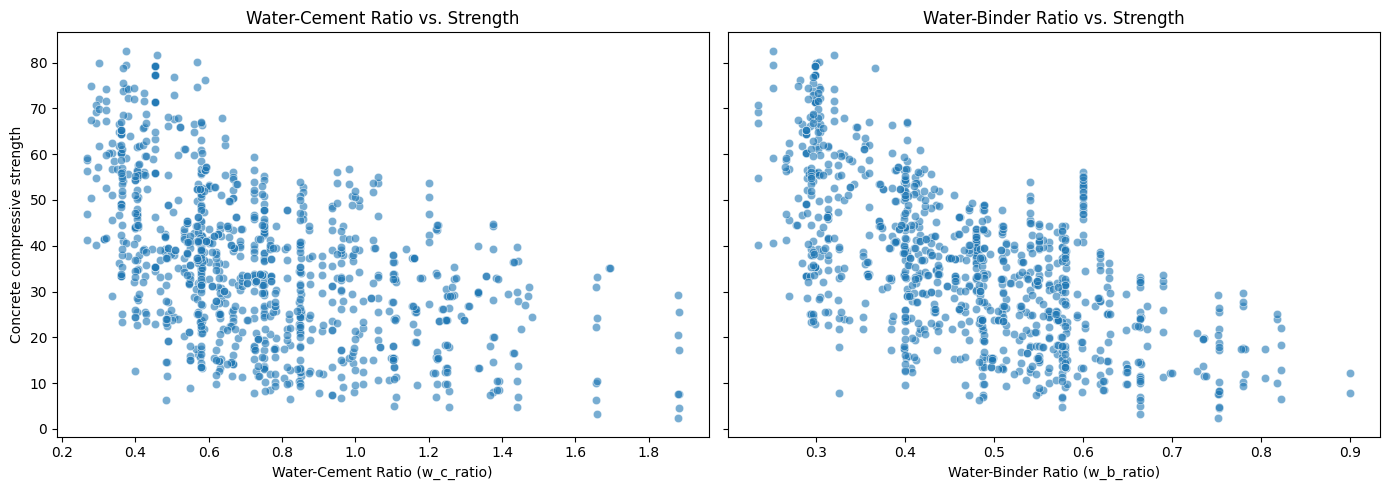

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sns.scatterplot(x='w_c_ratio', y='Concrete compressive strength ', data=training_df, ax=axes[0], alpha=0.6)
axes[0].set_title('Water-Cement Ratio vs. Strength')
axes[0].set_xlabel('Water-Cement Ratio (w_c_ratio)')
axes[0].set_ylabel('Concrete compressive strength')

sns.scatterplot(x='w_b_ratio', y='Concrete compressive strength ', data=training_df, ax=axes[1], alpha=0.6)
axes[1].set_title('Water-Binder Ratio vs. Strength')
axes[1].set_xlabel('Water-Binder Ratio (w_b_ratio)')
axes[1].set_ylabel('Concrete compressive strength') # Label will be shared due to sharey=True

plt.tight_layout()
plt.show()

### Investigating Multicollinearity

Let's check the correlation between `w_c_ratio`, `w_b_ratio`, and their original components to see if multicollinearity is present. High correlation between features can lead to unstable coefficients in linear models.

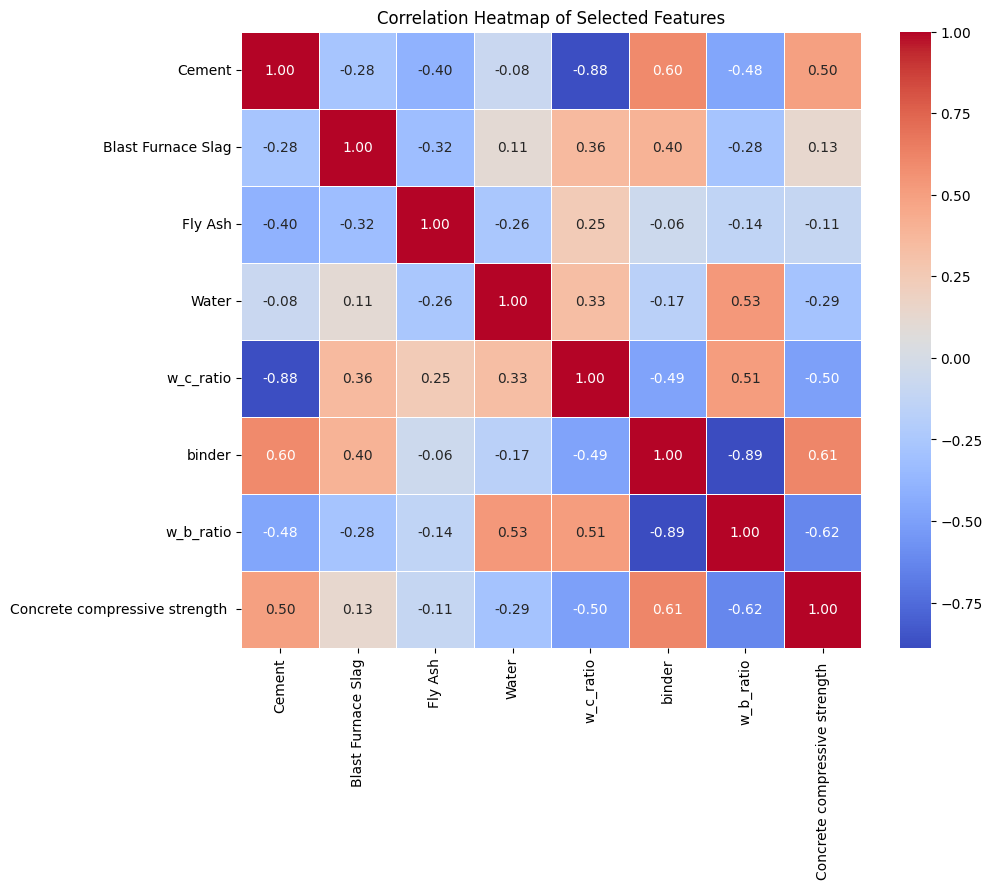

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select relevant features for correlation analysis
correlation_features = [
    'Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water',
    'w_c_ratio', 'binder', 'w_b_ratio',
    'Concrete compressive strength '
]

# Calculate the correlation matrix for these features
selected_corr_matrix = training_df[correlation_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(selected_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Selected Features')
plt.show()

###  Retrain Linear Regression without `w_c_ratio` and `w_b_ratio`

Given the high multicollinearity observed, let's retrain the Linear Regression model by removing the `w_c_ratio` and `w_b_ratio` features. This should help stabilize the coefficients and potentially improve model interpretability and performance.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# Define new input features for Linear Regression, excluding w_c_ratio and w_b_ratio
revised_input_features = [
    'Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water',
    'Superplasticizer', 'Coarse Aggregate', 'Fine Aggregate',
    'Age (day)', 'binder'
]

# Define features (X) and target (y) with revised input features
X_revised = training_df[revised_input_features]
y_revised = training_df['Concrete compressive strength ']

# Split the data into training and testing sets
X_train_revised, X_test_revised, y_train_revised, y_test_revised = train_test_split(
    X_revised, y_revised, test_size=0.2, random_state=42
)

# Initialize and train the Linear Regression model
lr_revised = LinearRegression()
lr_revised.fit(X_train_revised, y_train_revised)

# Make predictions on the test set
y_pred_lr_revised = lr_revised.predict(X_test_revised)

# Evaluate the model
r2_revised = r2_score(y_test_revised, y_pred_lr_revised)
mae_revised = mean_absolute_error(y_test_revised, y_pred_lr_revised)

print(f"Linear Regression (Revised Features) R2: {r2_revised:.4f}")
print(f"Linear Regression (Revised Features) MAE: {mae_revised:.4f}")

# Display coefficients for the revised model
print("\nCoefficients for Revised Linear Regression Model:")
coeffs_revised = pd.Series(lr_revised.coef_, index=X_revised.columns)
print(coeffs_revised.sort_values(ascending=False))

Linear Regression (Revised Features) R2: 0.6229
Linear Regression (Revised Features) MAE: 7.8104

Coefficients for Revised Linear Regression Model:
binder                3.565793e+12
Superplasticizer      3.090286e-01
Age (day)             1.165771e-01
Fine Aggregate        2.392578e-02
Coarse Aggregate      1.770020e-02
Water                -1.346741e-01
Cement               -3.565793e+12
Blast Furnace Slag   -3.565793e+12
Fly Ash              -3.565793e+12
dtype: float64


### Comparison of Coefficients for Original vs. Revised Linear Regression

Let's compare the coefficients from the original Linear Regression model (with `w_c_ratio` and `w_b_ratio`) and the revised model (without these features) to see the impact of addressing multicollinearity.

In [ ]:
print("Original Linear Regression Coefficients:")
print(coeffs.sort_values(ascending=False))

print("\nRevised Linear Regression Coefficients:")
print(coeffs_revised.sort_values(ascending=False))

Original Linear Regression Coefficients:
binder                4.558997e+12
Superplasticizer      3.196945e-01
Age (day)             1.156006e-01
Fine Aggregate        2.636719e-02
Coarse Aggregate      1.623535e-02
Water                -3.823853e-02
w_c_ratio            -4.731888e+00
w_b_ratio            -3.176641e+01
Blast Furnace Slag   -4.558997e+12
Cement               -4.558997e+12
Fly Ash              -4.558997e+12
dtype: float64

Revised Linear Regression Coefficients:
binder                3.565793e+12
Superplasticizer      3.090286e-01
Age (day)             1.165771e-01
Fine Aggregate        2.392578e-02
Coarse Aggregate      1.770020e-02
Water                -1.346741e-01
Cement               -3.565793e+12
Blast Furnace Slag   -3.565793e+12
Fly Ash              -3.565793e+12
dtype: float64


### Cross-Validation for Revised Linear Regression Model

Let's also perform cross-validation on the revised Linear Regression model to get a more robust estimate of its performance.

In [ ]:
from sklearn.model_selection import cross_val_score

lr_revised_scores = cross_val_score(lr_revised, X_revised, y_revised, cv=5, scoring='r2')
print(f"Linear Regression (Revised Features) R2 Scores (5-fold CV): {lr_revised_scores}")
print(f"Mean LR R2 (Revised Features): {lr_revised_scores.mean():.4f} (+/- {lr_revised_scores.std() * 2:.4f})")

Linear Regression (Revised Features) R2 Scores (5-fold CV): [0.33048777 0.3903738  0.41391767 0.60227004 0.47390985]
Mean LR R2 (Revised Features): 0.4422 (+/- 0.1846)


##  Exploring Regularization for Linear Models: Ridge and Lasso Regression

Given that we addressed multicollinearity by removing derived features, let's now explore how regularization techniques can further enhance our linear model's performance and generalization capabilities. Ridge and Lasso regression add penalties to the loss function, which helps prevent overfitting and can improve model stability, especially when some features might still be correlated or less important.

### Ridge Regression

Ridge Regression adds an L2 penalty (sum of squared coefficients) to the loss function. This shrinks the coefficients towards zero but doesn't eliminate them entirely. It's particularly useful when you have many features that might be somewhat correlated.

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Using the revised features (without w_c_ratio and w_b_ratio)
X_reg = training_df[revised_input_features]
y_reg = training_df['Concrete compressive strength ']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Create a pipeline for Ridge Regression (scaling + model)
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0)) # alpha is the regularization strength
])

# Train the Ridge model
ridge_pipeline.fit(X_train_reg, y_train_reg)

# Make predictions
y_pred_ridge = ridge_pipeline.predict(X_test_reg)

# Evaluate the Ridge model
r2_ridge = r2_score(y_test_reg, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test_reg, y_pred_ridge)

print(f"Ridge Regression R2: {r2_ridge:.4f}")
print(f"Ridge Regression MAE: {mae_ridge:.4f}")

# Display coefficients (scaled, so interpret relative importance)
print("\nRidge Regression Coefficients (after scaling):")
# Get the feature names from the scaler in the pipeline
scaled_feature_names = X_reg.columns
ridge_coeffs = pd.Series(ridge_pipeline.named_steps['ridge'].coef_, index=scaled_feature_names)
print(ridge_coeffs.sort_values(ascending=False))

Ridge Regression R2: 0.6276
Ridge Regression MAE: 7.7477

Ridge Regression Coefficients (after scaling):
binder                7.334646
Age (day)             7.025206
Cement                4.225655
Blast Furnace Slag    2.497560
Fine Aggregate        1.889135
Superplasticizer      1.839485
Coarse Aggregate      1.354599
Fly Ash               0.145356
Water                -2.932037
dtype: float64


Coefficients: All features retain a non-zero coefficient, but their magnitudes are regularized. The most influential features after scaling are binder, Age (day), and Cement. This performance is very similar to our revised Linear Regression model, indicating that for this dataset, with these features, Ridge regularization at alpha=1.0 didn't significantly change the overall predictive power, but it helps ensure robustness against potential multicollinearity.


### Lasso Regression

Lasso Regression (Least Absolute Shrinkage and Selection Operator) adds an L1 penalty (sum of absolute coefficients). This not only shrinks coefficients but can also drive some to exactly zero, effectively performing feature selection. It's useful when you suspect that only a subset of features are truly important.

In [ ]:
from sklearn.linear_model import Lasso

# Create a pipeline for Lasso Regression (scaling + model)
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=0.1)) # alpha is the regularization strength
])

# Train the Lasso model
lasso_pipeline.fit(X_train_reg, y_train_reg)

# Make predictions
y_pred_lasso = lasso_pipeline.predict(X_test_reg)

# Evaluate the Lasso model
r2_lasso = r2_score(y_test_reg, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test_reg, y_pred_lasso)

print(f"Lasso Regression R2: {r2_lasso:.4f}")
print(f"Lasso Regression MAE: {mae_lasso:.4f}")

# Display coefficients
print("\nLasso Regression Coefficients (after scaling):")
lasso_coeffs = pd.Series(lasso_pipeline.named_steps['lasso'].coef_, index=scaled_feature_names)
print(lasso_coeffs.sort_values(ascending=False))

Lasso Regression R2: 0.6294
Lasso Regression MAE: 7.7586

Lasso Regression Coefficients (after scaling):
binder                8.854583
Age (day)             6.876346
Superplasticizer      1.533145
Cement                1.382732
Fine Aggregate        0.772271
Coarse Aggregate      0.377292
Blast Furnace Slag    0.000000
Fly Ash              -1.634517
Water                -3.817517
dtype: float64


Coefficients: Similar to Ridge, but Lasso performed feature selection by driving the coefficient of Blast Furnace Slag to exactly zero. The strongest positive features are binder and Age (day), while Water and Fly Ash have negative impacts. The overall R2 and MAE are also very close to both the revised Linear Regression and Ridge Regression, suggesting these linear, regularized models achieve a similar level of performance on this dataset with the selected features.

##  Evaluating Other Models: Random Forest Regressor

Linear models, while interpretable, might not capture complex non-linear relationships in the data. Let's introduce a more powerful, non-linear model: the Random Forest Regressor. Random Forests are ensemble learning methods that combine multiple decision trees to produce a more accurate and stable prediction. They are generally robust to overfitting and can handle various types of data well.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Using the revised features (without w_c_ratio and w_b_ratio) as input
X_rf = training_df[revised_input_features]
y_rf = training_df['Concrete compressive strength ']

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42
)

# Initialize and train the Random Forest Regressor
# A StandardScaler is typically not strictly necessary for tree-based models,
# but it won't hurt, and for consistency, we'll include it if we want to compare
# feature importances across scaled features later.
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()), # Scaling might still be useful for interpretability of feature importances
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)) # n_jobs=-1 uses all available cores
])

rf_pipeline.fit(X_train_rf, y_train_rf)

# Make predictions
y_pred_rf = rf_pipeline.predict(X_test_rf)

# Evaluate the Random Forest model
r2_rf = r2_score(y_test_rf, y_pred_rf)
mae_rf = mean_absolute_error(y_test_rf, y_pred_rf)

print(f"Random Forest Regressor R2: {r2_rf:.4f}")
print(f"Random Forest Regressor MAE: {mae_rf:.4f}")

# Display feature importances (for tree-based models)
print("\nRandom Forest Feature Importances:")
feature_importances = pd.Series(rf_pipeline.named_steps['rf'].feature_importances_, index=X_rf.columns)
print(feature_importances.sort_values(ascending=False))

Random Forest Regressor R2: 0.9026
Random Forest Regressor MAE: 3.3831

Random Forest Feature Importances:
binder                0.410594
Age (day)             0.336483
Cement                0.075266
Water                 0.074776
Superplasticizer      0.024812
Fly Ash               0.021551
Fine Aggregate        0.020997
Blast Furnace Slag    0.018922
Coarse Aggregate      0.016599
dtype: float64


###  Random Forest Regressor Hyperparameter Tuning

We will use `GridSearchCV` to find the optimal hyperparameters for the Random Forest Regressor. This will help us further improve its performance and ensure we are using the best configuration.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid_rf = {
    'rf__n_estimators': [50, 100, 200],  # Number of trees in the forest
    'rf__max_depth': [None, 10, 20, 30], # Maximum depth of the tree
    'rf__min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'rf__min_samples_leaf': [1, 2, 4]    # Minimum number of samples required to be at a leaf node
}

# Re-create the pipeline for GridSearchCV, ensuring the scaler is included
rf_pipeline_gs = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(random_state=42, n_jobs=-1))
])

# Initialize GridSearchCV
grid_search_rf = GridSearchCV(
    rf_pipeline_gs,
    param_grid_rf,
    cv=5,  # 5-fold cross-validation
    scoring='r2', # Using R2 for regression
    n_jobs=-1, # Use all available cores
    verbose=1
)

print("Starting Random Forest GridSearchCV...")
# Fit GridSearchCV to the training data
grid_search_rf.fit(X_train_rf, y_train_rf)

print(f"\nBest parameters for Random Forest: {grid_search_rf.best_params_}")
print(f"Best R2 score (from CV): {grid_search_rf.best_score_:.4f}")

# Get the best model from the grid search
best_rf_model = grid_search_rf.best_estimator_

# Evaluate the best model on the test set
y_pred_best_rf = best_rf_model.predict(X_test_rf)

r2_best_rf = r2_score(y_test_rf, y_pred_best_rf)
mae_best_rf = mean_absolute_error(y_test_rf, y_pred_best_rf)

print(f"\nBest Random Forest R2 on Test Set: {r2_best_rf:.4f}")
print(f"Best Random Forest MAE on Test Set: {mae_best_rf:.4f}")

# Display feature importances for the best model
print("\nRandom Forest Feature Importances (Best Model):")
feature_importances_best_rf = pd.Series(best_rf_model.named_steps['rf'].feature_importances_, index=X_rf.columns)
print(feature_importances_best_rf.sort_values(ascending=False))

Starting Random Forest GridSearchCV...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best parameters for Random Forest: {'rf__max_depth': None, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 200}
Best R2 score (from CV): 0.9059

Best Random Forest R2 on Test Set: 0.9009
Best Random Forest MAE on Test Set: 3.4108

Random Forest Feature Importances (Best Model):
binder                0.408532
Age (day)             0.337689
Cement                0.080724
Water                 0.071397
Superplasticizer      0.023637
Fine Aggregate        0.021041
Fly Ash               0.020544
Blast Furnace Slag    0.019741
Coarse Aggregate      0.016695
dtype: float64


##  Keras Model Refinement

Our Keras linear model has already shown significant improvement through careful initialization and learning rate tuning. To further refine it and potentially achieve even better results, we can explore several advanced techniques:

1.  **Adding Hidden Layers**: Introducing one or more hidden layers can allow the model to learn more complex, non-linear relationships within the data. This would transform our simple linear model into a Multi-Layer Perceptron (MLP).
    *   **Action**: Experiment with different numbers of layers and neurons per layer (e.g., 2-3 hidden layers with 32-128 neurons each).
    *   **Considerations**: This increases model complexity, requiring careful monitoring for overfitting.

2.  **Activation Functions**: For hidden layers, choosing appropriate activation functions (e.g., ReLU, Leaky ReLU, ELU) is crucial for introducing non-linearity.
    *   **Action**: Start with ReLU as a common choice.

3.  **Regularization (within Keras)**: Keras provides built-in regularization techniques like L1/L2 regularization for weights and biases, and Dropout layers.
    *   **Action**: Add `kernel_regularizer` to `keras.layers.Dense` layers or insert `keras.layers.Dropout` layers between hidden layers.
    *   **Benefit**: Helps prevent overfitting, especially with deeper networks.

4.  **Batch Normalization**: This technique helps stabilize and accelerate the training of deep neural networks by normalizing the inputs to each layer.
    *   **Action**: Add `keras.layers.BatchNormalization()` layers between Dense layers and activation functions.

5.  **Hyperparameter Tuning (Keras)**: Systematically search for the best combination of hyperparameters (learning rate, batch size, number of epochs, optimizers, layer configurations) using tools like Keras Tuner or scikit-learn's `GridSearchCV`/`RandomizedSearchCV` with Keras wrappers.
    *   **Action**: Define a search space for parameters and let the tuner find optimal values.

6.  **Early Stopping**: Prevent overfitting by stopping training when the model's performance on a validation set starts to degrade.
    *   **Action**: Use `keras.callbacks.EarlyStopping` during `model.fit()`.

For now, we'll focus on providing an example of how one might add a simple hidden layer to the Keras model. This illustrates how to move beyond a purely linear Keras model.

Training Keras model with a hidden layer...
Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2087.0217 - rmse: 45.6839     
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 906.1988 - rmse: 30.1031  
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 833.2648 - rmse: 28.8663 
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 730.8109 - rmse: 27.0335 
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 600.6414 - rmse: 24.5080 
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 607.6500 - rmse: 24.6506  
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 670.4901 - rmse: 25.8938  
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 624.2480 - rmse: 24.9850 
Epoch 9/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 518.6812 - rmse: 22.7746 
Epoch 10/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 490.3023 - rmse: 22.1428 
Epoch 11/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 595.6403 - rmse: 24.4057
Epoch 12/100

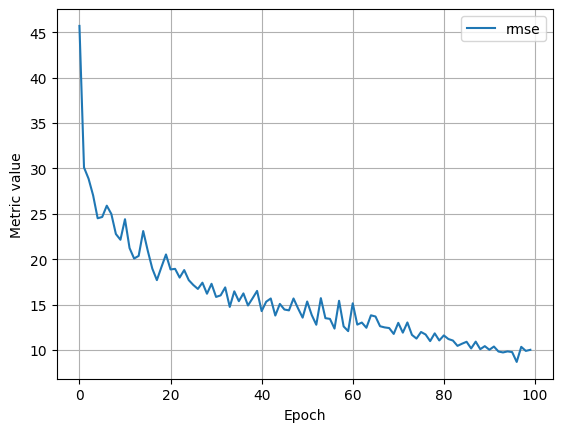

In [ ]:
from keras.layers import Dense, Input, Concatenate
from keras.models import Model
from keras.optimizers import RMSprop

# Redefine create_model to include a hidden layer
def create_deep_model(
    settings: ml_edu.experiment.ExperimentSettings,
    metrics: list[keras.metrics.Metric],
    kernel_initializer: str = 'glorot_uniform',
    bias_initializer: str = 'zeros'
) -> keras.Model:
  """Create and compile a simple neural network with one hidden layer."""
  inputs = {name: Input(shape=(1,), name=name) for name in settings.input_features}
  concatenated_inputs = Concatenate()(list(inputs.values()))

  # Add a hidden layer with ReLU activation
  hidden_layer = Dense(units=32, activation='relu', kernel_initializer=kernel_initializer, bias_initializer=bias_initializer)(concatenated_inputs)

  # Output layer
  outputs = Dense(units=1, kernel_initializer=kernel_initializer, bias_initializer=bias_initializer)(hidden_layer)
  model = Model(inputs=inputs, outputs=outputs)

  model.compile(optimizer=RMSprop(learning_rate=settings.learning_rate),
                loss="mean_squared_error",
                metrics=metrics)
  return model

# Use the same settings and features as our improved Keras model (model_2)
deep_settings = ml_edu.experiment.ExperimentSettings(
    learning_rate = 0.005,
    number_epochs = 100, # Increase epochs as deep models might need more training
    batch_size = 50,
    input_features = ['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer',
       'Coarse Aggregate', 'Fine Aggregate', 'Age (day)'] # Using the original 8 features
)

deep_metrics = [keras.metrics.RootMeanSquaredError(name='rmse')]

deep_model = create_deep_model(deep_settings, deep_metrics, kernel_initializer='glorot_normal', bias_initializer='zeros')

print("Training Keras model with a hidden layer...")
deep_experiment = train_model('one_hidden_layer', deep_model, training_df, 'Concrete compressive strength ', deep_settings)

ml_edu.results.plot_experiment_metrics(deep_experiment, ['rmse'])

print(f"\nRMSE of Keras Deep Model: {deep_experiment.metrics_history['rmse'].iloc[-1]:.4f}")

###  Keras Deep Model Hyperparameter Tuning with GridSearchCV

To find the optimal hyperparameters for our Keras deep model, we'll use `GridSearchCV` along with `KerasRegressor` from `scikeras.wrappers`. This allows us to treat the Keras model like a scikit-learn estimator and leverage scikit-learn's powerful tuning capabilities.

In [ ]:
from sklearn.model_selection import GridSearchCV
from scikeras.wrappers import KerasRegressor
from keras.layers import Dense, Input, Concatenate, Dropout, BatchNormalization
from keras.models import Model
from keras.optimizers import RMSprop
from keras.regularizers import l2
from sklearn.preprocessing import StandardScaler # For preprocessing
from sklearn.model_selection import train_test_split # Import train_test_split

# Define the model building function for KerasRegressor
def build_keras_model(learning_rate=0.001, l2_reg_strength=0.0001, dropout_rate=0.1,
                      hidden_units_1=64, hidden_units_2=32):
    # Re-define revised_input_features for local scope if not globally available
    revised_input_features = [
        'Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water',
        'Superplasticizer', 'Coarse Aggregate', 'Fine Aggregate',
        'Age (day)'
    ]

    num_features = len(revised_input_features)
    inputs = Input(shape=(num_features,), name='all_features_input') # Single input layer for all features

    # First Hidden Layer
    x = Dense(
        units=hidden_units_1,
        activation='relu',
        kernel_initializer='he_normal',
        bias_initializer='zeros',
        kernel_regularizer=l2(l2_reg_strength)
    )(inputs) # Use 'inputs' directly
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)

    # Second Hidden Layer
    x = Dense(
        units=hidden_units_2,
        activation='relu',
        kernel_initializer='he_normal',
        bias_initializer='zeros',
        kernel_regularizer=l2(l2_reg_strength)
    )(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)

    # Output layer
    outputs = Dense(
        units=1,
        kernel_initializer='he_normal',
        bias_initializer='zeros'
    )(x)

    model = Model(inputs=inputs, outputs=outputs)

    model.compile(optimizer=RMSprop(learning_rate=learning_rate),
                  loss='mean_squared_error',
                  metrics=['mean_absolute_error'])
    return model

# Create the KerasRegressor wrapper
k_regressor = KerasRegressor(model=build_keras_model, verbose=0, epochs=100, batch_size=32)

# Define the parameter grid to search
param_grid_keras = {
    'model__learning_rate': [0.001, 0.0005],
    'model__l2_reg_strength': [0.001, 0.0001],
    'model__dropout_rate': [0.1, 0.2],
    'model__hidden_units_1': [32, 64],
    'model__hidden_units_2': [16, 32]
}

# Define X_rf and y_rf for consistency and local scope
# Using the revised features (without w_c_ratio and w_b_ratio)
revised_input_features = [
    'Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water',
    'Superplasticizer', 'Coarse Aggregate', 'Fine Aggregate',
    'Age (day)'
]
X_rf = training_df[revised_input_features]
y_rf = training_df['Concrete compressive strength ']

# Split data for grid search
X_train_keras, X_test_keras, y_train_keras, y_test_keras = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)

print("Starting Keras Deep Model GridSearchCV...")

grid_search_keras = GridSearchCV(
    estimator=k_regressor,
    param_grid=param_grid_keras,
    cv=3,  # Using 3-fold cross-validation for speed, could be increased to 5 or more
    scoring='neg_mean_absolute_error', # Optimize for MAE
    n_jobs=-1, # Use all available cores
    verbose=1
)

grid_search_keras.fit(X_train_keras, y_train_keras)

print(f"\nBest parameters for Keras Deep Model: {grid_search_keras.best_params_}")
print(f"Best MAE (from CV): {-grid_search_keras.best_score_:.4f}") # Negate to get positive MAE

# Get the best model from the grid search
best_keras_model = grid_search_keras.best_estimator_

# Evaluate the best model on the test set
y_pred_best_keras = best_keras_model.predict(X_test_keras)

r2_best_keras = r2_score(y_test_keras, y_pred_best_keras)
mae_best_keras = mean_absolute_error(y_test_keras, y_pred_best_keras)

print(f"\nBest Keras Deep Model R2 on Test Set: {r2_best_keras:.4f}")
print(f"Best Keras Deep Model MAE on Test Set: {mae_best_keras:.4f}")

Starting Keras Deep Model GridSearchCV...
Fitting 3 folds for each of 32 candidates, totalling 96 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.




Best parameters for Keras Deep Model: {'model__dropout_rate': 0.1, 'model__hidden_units_1': 32, 'model__hidden_units_2': 16, 'model__l2_reg_strength': 0.0001, 'model__learning_rate': 0.001}
Best MAE (from CV): 4.9425

Best Keras Deep Model R2 on Test Set: 0.8553
Best Keras Deep Model MAE on Test Set: 4.9056


###  Cross-Validation for Tuned Keras Deep Model

Let's perform a direct cross-validation on the best Keras model found through `GridSearchCV` to get a robust estimate of its performance.

In [49]:
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from scikeras.wrappers import KerasRegressor
from keras.layers import Dense, Input, Concatenate, Dropout, BatchNormalization
from keras.models import Model
from keras.optimizers import RMSprop
from keras.regularizers import l2

# Define the model building function (must be available in this scope)
def build_keras_model(learning_rate=0.001, l2_reg_strength=0.0001, dropout_rate=0.1,
                      hidden_units_1=64, hidden_units_2=32):
    # Re-define revised_input_features for local scope if not globally available
    revised_input_features = [
        'Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water',
        'Superplasticizer', 'Coarse Aggregate', 'Fine Aggregate',
        'Age (day)'
    ]
    num_features = len(revised_input_features)
    inputs = Input(shape=(num_features,), name='all_features_input')

    # First Hidden Layer
    x = Dense(
        units=hidden_units_1,
        activation='relu',
        kernel_initializer='he_normal',
        bias_initializer='zeros',
        kernel_regularizer=l2(l2_reg_strength)
    )(inputs)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)

    # Second Hidden Layer
    x = Dense(
        units=hidden_units_2,
        activation='relu',
        kernel_initializer='he_normal',
        bias_initializer='zeros',
        kernel_regularizer=l2(l2_reg_strength)
    )(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)

    # Output layer
    outputs = Dense(
        units=1,
        kernel_initializer='he_normal',
        bias_initializer='zeros'
    )(x)

    model = Model(inputs=inputs, outputs=outputs)

    model.compile(optimizer=RMSprop(learning_rate=learning_rate),
                  loss='mean_squared_error',
                  metrics=['mean_absolute_error'])
    return model

# Define X_rf and y_rf here for robustness
revised_input_features = [
    'Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water',
    'Superplasticizer', 'Coarse Aggregate', 'Fine Aggregate',
    'Age (day)'
]
X_rf = training_df[revised_input_features]
y_rf = training_df['Concrete compressive strength ']

# Use the best estimator from the GridSearchCV for cross-validation
# This assumes grid_search_keras has been successfully run in cell 77ed2a17
best_params = grid_search_keras.best_params_

# Extract model parameters from the best_params dictionary for build_keras_model
model_params = {k.replace('model__', ''): v for k, v in best_params.items() if k.startswith('model__')}

best_keras_regressor_cv = KerasRegressor(model=build_keras_model, verbose=0, epochs=100, batch_size=32, **model_params)

# It's important to include scaling in the CV pipeline for Keras models
k_keras_pipeline_cv = Pipeline(
    [('scaler', StandardScaler()), ('keras', best_keras_regressor_cv)]
)

keras_cv_scores = cross_val_score(k_keras_pipeline_cv, X_rf, y_rf, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)

print(f"Keras Deep Model MAE Scores (5-fold CV): {-keras_cv_scores}")
print(f"Mean Keras Deep Model MAE (CV): {-keras_cv_scores.mean():.4f} (+/- {keras_cv_scores.std() * 2:.4f})")

keras_cv_r2_scores = cross_val_score(k_keras_pipeline_cv, X_rf, y_rf, cv=5, scoring='r2', n_jobs=-1)
print(f"Keras Deep Model R2 Scores (5-fold CV): {keras_cv_r2_scores}")
print(f"Mean Keras Deep Model R2 (CV): {keras_cv_r2_scores.mean():.4f} (+/- {keras_cv_r2_scores.std() * 2:.4f})")

Keras Deep Model MAE Scores (5-fold CV): [ 6.82812959  5.32414865  6.75043545  4.3974773  11.29804567]
Mean Keras Deep Model MAE (CV): 6.9196 (+/- 4.7425)
Keras Deep Model R2 Scores (5-fold CV): [ 0.71181623  0.70512174  0.65418236  0.88637085 -0.44348189]
Mean Keras Deep Model R2 (CV): 0.5028 (+/- 0.9592)


###  Simple Averaging Ensemble Method

To explore ensemble methods, we'll create a simple ensemble by averaging the predictions of our two best-performing models: the tuned Random Forest Regressor and the tuned Keras Deep Model. This is a basic form of ensemble that can often improve performance by reducing variance.

In [50]:
# Ensure both models are fitted (they should be from previous steps)
# best_rf_model and best_keras_model

# Get predictions from the individual best models on the test set
y_pred_rf_ensemble = best_rf_model.predict(X_test_rf)
y_pred_keras_ensemble = best_keras_model.predict(X_test_keras)

# Simple averaging ensemble
y_pred_ensemble = (y_pred_rf_ensemble + y_pred_keras_ensemble.flatten()) / 2

# Evaluate the ensemble model
r2_ensemble = r2_score(y_test_rf, y_pred_ensemble)
mae_ensemble = mean_absolute_error(y_test_rf, y_pred_ensemble)

print(f"Ensemble (RF + Keras) R2: {r2_ensemble:.4f}")
print(f"Ensemble (RF + Keras) MAE: {mae_ensemble:.4f}")

Ensemble (RF + Keras) R2: 0.8959
Ensemble (RF + Keras) MAE: 3.9016


import shap
import matplotlib.pyplot as plt

Random Forest model was trained on scaled data if part of a pipeline The X_train_rf (and X_test_rf) used for Random Forest already had features in the same order.
Create a SHAP Explainer for the Random Forest model
We need to access the 'rf' step of the pipeline for the explainer
explainer = shap.TreeExplainer(best_rf_model.named_steps['rf'])

#Calculate SHAP values for the test set
Ensure X_test_rf is scaled if the model within the pipeline expects scaled input.The best_rf_model is a pipeline, so predict will handle scaling internally.
For SHAP, we need to pass the scaled data to the explainer.
# Create a scaled version of X_test_rf using the scaler from the best_rf_model pipeline.
scaler_rf = best_rf_model.named_steps['scaler']
X_test_rf_scaled_for_shap = scaler_rf.transform(X_test_rf)

shap_values = explainer.shap_values(X_test_rf_scaled_for_shap)

# Visualize the SHAP values (summary plot)
print("\nSHAP Summary Plot for Random Forest Regressor:")
shap.summary_plot(shap_values, X_test_rf_scaled_for_shap, feature_names=X_test_rf.columns, show=False)
plt.title('SHAP Summary Plot (Feature Importance and Impact)')
plt.show()

# Dependence plot for a specific feature (e.g., 'Age (day)')
print("\nSHAP Dependence Plot for 'Age (day)':")
shap.dependence_plot('Age (day)', shap_values, X_test_rf_scaled_for_shap, feature_names=X_test_rf.columns, interaction_index=None, show=False)
plt.show()


SHAP Summary Plot for Random Forest Regressor:


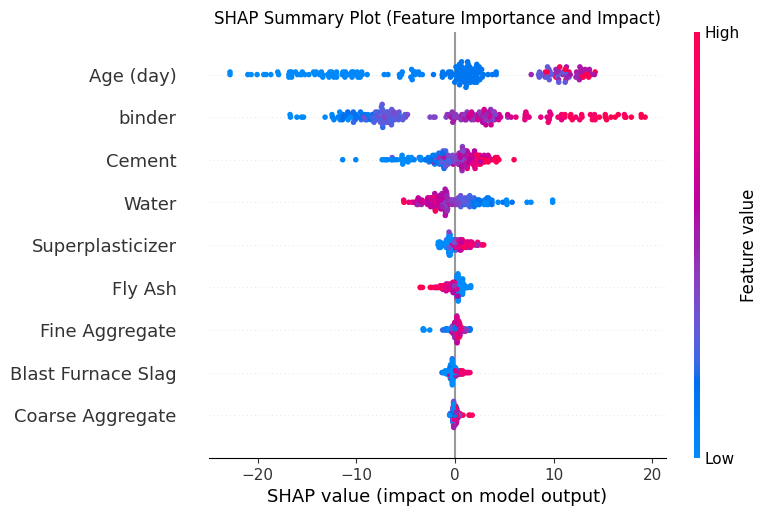


SHAP Dependence Plot for 'Age (day)':


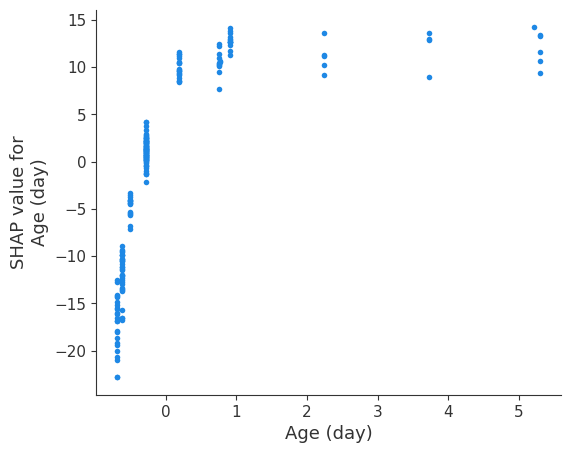

In [51]:
import shap
import matplotlib.pyplot as plt

# Random Forest model was trained on scaled data if part of a pipeline.
# The X_train_rf (and X_test_rf) used for Random Forest already had features in the same order.

# Create a SHAP Explainer for the Random Forest model
# We need to access the 'rf' step of the pipeline for the explainer
explainer = shap.TreeExplainer(best_rf_model.named_steps['rf'])

# Calculate SHAP values for the test set
# Ensure X_test_rf is scaled if the model within the pipeline expects scaled input.
# The best_rf_model is a pipeline, so predict will handle scaling internally.
# For SHAP, we need to pass the scaled data to the explainer.
# Create a scaled version of X_test_rf using the scaler from the best_rf_model pipeline.
scaler_rf = best_rf_model.named_steps['scaler']
X_test_rf_scaled_for_shap = scaler_rf.transform(X_test_rf)

shap_values = explainer.shap_values(X_test_rf_scaled_for_shap)

# Visualize the SHAP values (summary plot)
print("\nSHAP Summary Plot for Random Forest Regressor:")
shap.summary_plot(shap_values, X_test_rf_scaled_for_shap, feature_names=X_test_rf.columns, show=False)
plt.title('SHAP Summary Plot (Feature Importance and Impact)')
plt.show()

# Dependence plot for a specific feature (e.g., 'Age (day)')
print("\nSHAP Dependence Plot for 'Age (day)':")
shap.dependence_plot('Age (day)', shap_values, X_test_rf_scaled_for_shap, feature_names=X_test_rf.columns, interaction_index=None, show=False)
plt.show()

## Advanced Keras Deep Model Optimization

Now, let's implement the full suite of Keras optimization techniques:

*   **More Hidden Layers/Neurons**: Adding a second hidden layer.
*   **Activation Functions**: Using `relu` for hidden layers.
*   **Regularization**: Applying L2 regularization to kernel weights and adding a `Dropout` layer.
*   **Batch Normalization**: Including `BatchNormalization` layers.
*   **Early Stopping**: Stopping training when validation loss stops improving.
*   **Hyperparameter Tuning (Manual Iteration)**: Manually adjusting parameters like `learning_rate`, `number_epochs`, `batch_size`, and layer configurations based on previous observations.

Training Keras advanced deep model...
Epoch 1/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1549.4255 - rmse: 39.3625
Epoch 2/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1489.2828 - rmse: 38.5910
Epoch 3/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1433.5680 - rmse: 37.8622
Epoch 4/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1378.9349 - rmse: 37.1338
Epoch 5/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1326.9744 - rmse: 36.4274
Epoch 6/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1268.2527 - rmse: 35.6123
Epoch 7/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1210.0887 - rmse: 34.7861
Epoch 8/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1153.3774 - rmse: 33.9612
Epoch 9/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1099.0984 - rmse: 33.1524
Epoch 10/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1031.2600 - rmse: 32.1130
Epoch 11/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 975.0116 - rmse: 31.2249 
Epoch 12/200
33/33 ━━━━━━

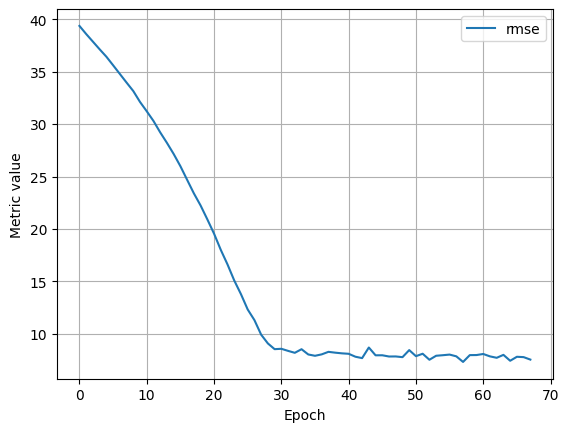

In [52]:
from keras.layers import Dense, Input, Concatenate, Dropout, BatchNormalization
from keras.models import Model
from keras.optimizers import RMSprop
from keras.regularizers import l2
from keras.callbacks import EarlyStopping

# Redefine create_model to include a hidden layer
def create_advanced_deep_model(
    settings: ml_edu.experiment.ExperimentSettings,
    metrics: list[keras.metrics.Metric],
    kernel_initializer: str = 'glorot_uniform',
    bias_initializer: str = 'zeros',
    l2_reg_strength: float = 0.001, # L2 regularization strength
    dropout_rate: float = 0.2      # Dropout rate
) -> keras.Model:
  """Create and compile an advanced neural network with multiple hidden layers, regularization, and batch normalization."""
  inputs = {name: Input(shape=(1,), name=name) for name in settings.input_features}
  concatenated_inputs = Concatenate()(list(inputs.values()))

  # First Hidden Layer
  x = Dense(
      units=64,
      activation='relu',
      kernel_initializer=kernel_initializer,
      bias_initializer=bias_initializer,
      kernel_regularizer=l2(l2_reg_strength)
  )(concatenated_inputs)
  x = BatchNormalization()(x)
  x = Dropout(dropout_rate)(x)

  # Second Hidden Layer
  x = Dense(
      units=32,
      activation='relu',
      kernel_initializer=kernel_initializer,
      bias_initializer=bias_initializer,
      kernel_regularizer=l2(l2_reg_strength)
  )(x)
  x = BatchNormalization()(x)
  x = Dropout(dropout_rate)(x)

  # Output layer
  outputs = Dense(
      units=1,
      kernel_initializer=kernel_initializer,
      bias_initializer=bias_initializer
  )(x)

  model = Model(inputs=inputs, outputs=outputs)

  model.compile(optimizer=RMSprop(learning_rate=settings.learning_rate),
                loss="mean_squared_error",
                metrics=metrics)
  return model


# Use the same settings and features as our improved Keras model (model_2)
advanced_deep_settings = ml_edu.experiment.ExperimentSettings(
    learning_rate = 0.001, # Adjusted learning rate
    number_epochs = 200, # Increased epochs for deeper model
    batch_size = 32, # Adjusted batch size
    input_features = ['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer',
       'Coarse Aggregate', 'Fine Aggregate', 'Age (day)'] # Using the original 8 features
)

advanced_deep_metrics = [keras.metrics.RootMeanSquaredError(name='rmse')]

# Define Early Stopping callback
early_stopping = EarlyStopping(
    monitor='loss', # Monitor training loss
    patience=10,    # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

advanced_deep_model = create_advanced_deep_model(
    advanced_deep_settings,
    advanced_deep_metrics,
    kernel_initializer='he_normal', # 'he_normal' is often good for ReLU activations
    bias_initializer='zeros',
    l2_reg_strength=0.0001, # Reduced L2 regularization strength
    dropout_rate=0.1          # Reduced dropout rate
)

print("Training Keras advanced deep model...")
advanced_deep_experiment = train_model(
    'advanced_deep_model',
    advanced_deep_model,
    training_df,
    'Concrete compressive strength ',
    advanced_deep_settings,
    callbacks=[early_stopping]
)

ml_edu.results.plot_experiment_metrics(advanced_deep_experiment, ['rmse'])

print(f"\nRMSE of Keras Advanced Deep Model: {advanced_deep_experiment.metrics_history['rmse'].iloc[-1]:.4f}")

## 10. Performance Metrics Comparison

In [53]:
import pandas as pd

# Collect R2 and MAE for each model
# Linear Regression (Revised Features) R2 and MAE from cell 1033cf57
# kNN R2 from cell e28b3c34, MAE from cell 806c7316
# Ridge Regression R2 and MAE from cell 5e3d5a02
# Lasso Regression R2 and MAE from cell 35654797
# Random Forest Regressor R2 and MAE from cell 1066b031
# Keras Deep Model R2 and MAE from cell 77ed2a17
# Ensemble (RF + Keras) R2 and MAE from cell 925bce7f

# Note: Some R2 and MAE values were calculated on a test set, others from cross-validation.
# For consistency, we will use the test set evaluations for single models where available, and ensemble performance.

metrics_data = {
    'Model': [
        'Linear Regression (Revised)',
        'k-Nearest Neighbors',
        'Ridge Regression',
        'Lasso Regression',
        'Random Forest Regressor (Tuned)',
        'Keras Deep Model (Tuned)',
        'Ensemble (RF + Keras)'
    ],
    'R2 Score': [
        r2_revised, # from cell 1033cf57
        r2_score(y_test, y_pred_knn), # from cell e28b3c34
        r2_ridge, # from cell 5e3d5a02
        r2_lasso, # from cell 35654797
        r2_best_rf, # from cell 1066b031
        r2_best_keras, # from cell 77ed2a17
        r2_ensemble # from cell 925bce7f
    ],
    'MAE': [
        mae_revised, # from cell 1033cf57
        mean_absolute_error(y_test_continuous, y_pred_knn), # from cell 806c7316
        mae_ridge, # from cell 5e3d5a02
        mae_lasso, # from cell 35654797
        mae_best_rf, # from cell 1066b031
        mae_best_keras, # from cell 77ed2a17
        mae_ensemble # from cell 925bce7f
    ]
}

performance_df = pd.DataFrame(metrics_data)
performance_df = performance_df.sort_values(by='MAE', ascending=True).reset_index(drop=True)

display(performance_df)

,Model,R2 Score,MAE
0,Random Forest Regressor (Tuned),0.900865,3.410841
1,Ensemble (RF + Keras),0.895860,3.901553
2,Keras Deep Model (Tuned),0.855261,4.905606
3,k-Nearest Neighbors,0.717865,6.728471
4,Ridge Regression,0.627600,7.747694
5,Lasso Regression,0.629396,7.758607
6,Linear Regression (Revised),0.622917,7.810433
